In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install grad-cam
import torch
import timm
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

import torchvision.models as models

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 100.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=20070939624025cb7c8aea992189c5ce32eddf4d44d101ebcdd4fd5d6ee7f12f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Loading swin models
binary_model_swin = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=2
)

binary_model_swin.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/swin_binary_best.pth"
))
binary_model_swin.to(device)
binary_model_swin.eval()


multi_model_swin = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=4
)

multi_model_swin.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/swin_multiclass_best.pth"
))
multi_model_swin.to(device)
multi_model_swin.eval()

print("Swin models loaded")

Swin models loaded


In [ ]:
# Loading EfficientNet model
efficientnet_model = models.efficientnet_b0()

efficientnet_model.classifier[1] = torch.nn.Linear(
    efficientnet_model.classifier[1].in_features, 4
)

efficientnet_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/efficientnet_b0_multiclass_best.pth"
))

efficientnet_model.to(device)
efficientnet_model.eval()

target_layer = efficientnet_model.features[-1]

print("EfficientNet loaded")

EfficientNet loaded


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d1 = self.up1(e4)
        d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)

        out = self.final(d3)

        return torch.sigmoid(out)

In [ ]:
# Loading UNet model
model = UNet()
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/unet_segmentation.pth"
))
model.to(device)
model.eval()

print("UNet loaded")

UNet loaded


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transform

In [ ]:
binary_classes = ['Abnormal', 'Normal']

multi_classes = [
    "Acute Otitis Media",
    "Chronic Otitis Media",
    "Myringosclerosis",
    "Cochlear Implant"
]

In [ ]:
# Segmentation
def segment_and_crop(image):

    img = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img)

    pred_mask = pred.squeeze().cpu().numpy()
    pred_mask = (pred_mask > 0.5).astype("uint8")

    image_np = np.array(image.resize((224,224)))

    roi = image_np.copy()
    roi[pred_mask == 0] = 0

    return Image.fromarray(roi), pred_mask

In [ ]:
def segment_and_crop(image):

    img = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img)

    pred_mask = pred.squeeze().cpu().numpy()
    pred_mask = (pred_mask > 0.5).astype("uint8")

    image_np = np.array(image.resize((224,224)))

    rgba = np.zeros((224,224,4), dtype=np.uint8)

    rgba[:,:,:3] = image_np

    rgba[:,:,3] = pred_mask * 255

    return Image.fromarray(rgba), pred_mask

In [ ]:
# GRAD CAM
def apply_gradcam(image):

    input_tensor = transform(image).unsqueeze(0).to(device)

    cam = GradCAM(model=efficientnet_model, target_layers=[target_layer])

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    image_np = np.array(image.resize((224,224))) / 255.0

    cam_image = show_cam_on_image(
        image_np.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    return cam_image

In [ ]:
# Final Pipeline
def final_pipeline(image_path):

    image = Image.open(image_path).convert("RGB")

    # 🔵 SEGMENTATION
    roi_image, mask = segment_and_crop(image)

    # 🔵 BINARY CLASSIFICATION
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        binary_out = binary_model_swin(input_tensor)
        binary_prob = torch.softmax(binary_out, dim=1)
        b_conf, b_pred = torch.max(binary_prob, 1)

    binary_label = binary_classes[b_pred.item()]

    # NORMAL CASE
    if binary_label == "Normal":
        return {
            "image": image,
            "roi": roi_image,
            "stage": "normal",
            "binary_conf": b_conf.item()
        }

    # MULTI-CLASS
    with torch.no_grad():
        multi_out = multi_model_swin(input_tensor)
        multi_prob = torch.softmax(multi_out, dim=1)
        m_conf, m_pred = torch.max(multi_prob, 1)

    disease = multi_classes[m_pred.item()]

    #  GRAD-CAM
    gradcam_img = apply_gradcam(image)

    return {
        "image": image,
        "roi": roi_image,
        "stage": "abnormal",
        "binary_conf": b_conf.item(),
        "disease": disease,
        "disease_conf": m_conf.item(),
        "gradcam": gradcam_img
    }

<Figure size 1000x400 with 0 Axes>

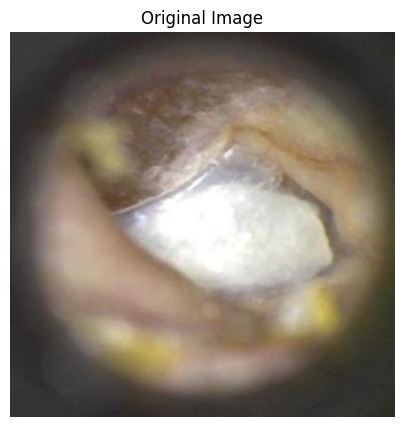

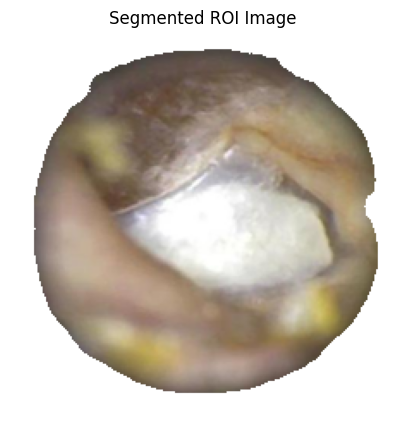


PREDICTION RESULT
Ear Condition: ABNORMAL
Binary Confidence: 0.97

Disease Detected: Cochlear Implant
Disease Confidence: 0.87


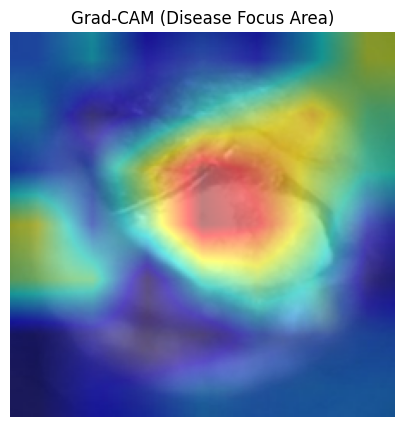

In [ ]:
image_path = "/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/mys-114-_jpg.rf.8289885fc5d68bd4b20bab6a0bc889dd.jpg"

result = final_pipeline(image_path)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# ORIGINAL IMAGE
plt.figure(figsize=(5,5))
plt.imshow(result["image"])
plt.title("Original Image")
plt.axis("off")
plt.show()


# ROI IMAGE
plt.figure(figsize=(5,5))
plt.imshow(result["roi"])
plt.title("Segmented ROI Image")
plt.axis("off")
plt.show()


print("\n========================")
print("PREDICTION RESULT")
print("========================")

if result["stage"] == "normal":

    print("Ear Condition: NORMAL")
    print(f"Confidence: {result['binary_conf']:.2f}")

else:

    print("Ear Condition: ABNORMAL")
    print(f"Binary Confidence: {result['binary_conf']:.2f}")

    print(f"\nDisease Detected: {result['disease']}")
    print(f"Disease Confidence: {result['disease_conf']:.2f}")

    plt.figure(figsize=(5,5))
    plt.imshow(result["gradcam"])
    plt.title("Grad-CAM (Disease Focus Area)")
    plt.axis("off")

<Figure size 1000x400 with 0 Axes>

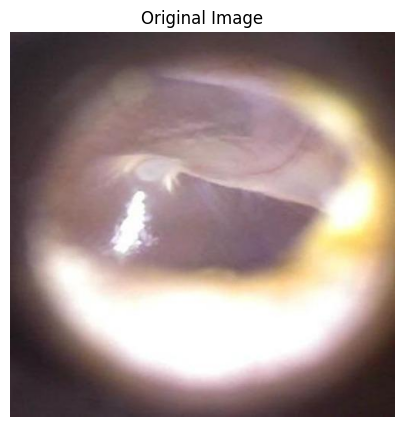

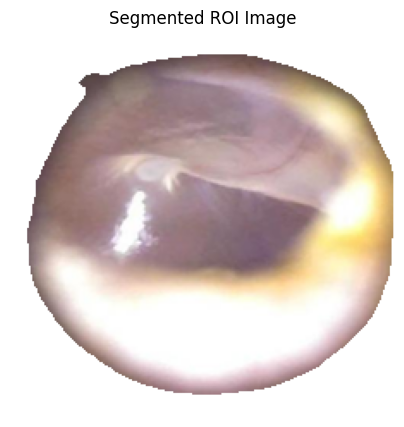


PREDICTION RESULT
Ear Condition: NORMAL
Confidence: 0.98


In [ ]:
image_path = "/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/norm-99-_jpg.rf.220b09fd0dcdf972cfa52a1bde6b5d05.jpg"

result = final_pipeline(image_path)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# ORIGINAL IMAGE
plt.figure(figsize=(5,5))
plt.imshow(result["image"])
plt.title("Original Image")
plt.axis("off")
plt.show()


# ROI IMAGE
plt.figure(figsize=(5,5))
plt.imshow(result["roi"])
plt.title("Segmented ROI Image")
plt.axis("off")
plt.show()


print("\n========================")
print("PREDICTION RESULT")
print("========================")

if result["stage"] == "normal":

    print("Ear Condition: NORMAL")
    print(f"Confidence: {result['binary_conf']:.2f}")

else:

    print("Ear Condition: ABNORMAL")
    print(f"Binary Confidence: {result['binary_conf']:.2f}")

    print(f"\nDisease Detected: {result['disease']}")
    print(f"Disease Confidence: {result['disease_conf']:.2f}")

    plt.figure(figsize=(5,5))
    plt.imshow(result["gradcam"])
    plt.title("Grad-CAM (Disease Focus Area)")
    plt.axis("off")

In [ ]:

import os
os.makedirs("/content/drive/MyDrive/EarProject/models", exist_ok=True)

# Save Swin Binary
torch.save(binary_model_swin.state_dict(),
           "/content/drive/MyDrive/EarProject/models/swin_binary_final.pth")

# Save Swin Multi
torch.save(multi_model_swin.state_dict(),
           "/content/drive/MyDrive/EarProject/models/swin_multiclass_final.pth")

# Save EfficientNet
torch.save(efficientnet_model.state_dict(),
           "/content/drive/MyDrive/EarProject/models/efficientnet_final.pth")

# Save UNet
torch.save(model.state_dict(),
           "/content/drive/MyDrive/EarProject/models/unet_final.pth")

print("All models saved successfully")

All models saved successfully


## **Streamlit Web Interface**

In [ ]:
import streamlit as st
import torch
import timm
import numpy as np
import cv2
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from io import BytesIO
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Image as RLImage, Spacer
from reportlab.lib.pagesizes import letter
from reportlab.platypus import PageBreak

st.set_page_config(layout="wide")

device = torch.device("cpu")
IMG_SIZE = 260

# ================= SESSION =================
if "page" not in st.session_state:
    st.session_state.page = "home"
if "role" not in st.session_state:
    st.session_state.role = None
if "image" not in st.session_state:
    st.session_state.image = None

# ================= HEADER =================
st.markdown("""
<h1 style='text-align:center; font-size:44px; font-weight:700; color:white; margin-bottom:10px;'>
Automated Ear Disease Classification System
</h1>
""", unsafe_allow_html=True)

import base64

def set_bg(image_file):
    with open(image_file, "rb") as f:
        data = base64.b64encode(f.read()).decode()

    st.markdown(f"""
    <style>
    .stApp {{
        background-image:
            linear-gradient(rgba(0,0,0,0.2), rgba(0,0,0,0.3)),
            url("data:image/jpg;base64,{data}");
        background-size: cover;
        background-position: center;
    }}
    </style>""", unsafe_allow_html=True)

# CALL FUNCTION
set_bg("background.jpg")
st.markdown("""
<style>

.glass-card {
    background: rgba(255,255,255,0.06);
    backdrop-filter: blur(14px);
    border-radius: 16px;
    padding: 12px;
    margin-bottom: 25px;
    border: 1px solid rgba(255,255,255,0.1);
}

/* Titles */
.section-title {
    font-size: 28px;
    font-weight: 700;
    color: #38BDF8;
    margin-bottom: 15px;
}

/* Result Text */
.result-text {
    font-size: 22px;
    font-weight: 600;
    color: #e2e8f0;
}

/* Info Text */
.info-text {
    font-size: 20px;
    line-height: 1.6;
    color: white;
}

.badge-normal, .badge-abnormal {
    color: white;
    padding: 8px 18px;
    border-radius: 20px;
    font-weight: bold;
    font-size: 16px;
}

.badge-normal {
    background: #2ECC71;
}

.badge-abnormal {
    background: #EF4444;
}

.badge-normal, .badge-abnormal {
    font-size: 18px;
    padding: 8px 20px;
}
* {
    transition: all 0.3s ease;
}

div.stButton > button {
    background: linear-gradient(135deg, #2563EB, #1E40AF);
    color: white;
    border-radius: 14px;
    width: 220px;
    height: 48px;
    font-size: 16px;
    font-weight: 600;
    margin: auto;
    display: block;
    border: none;
    transition: all 0.25s ease;
}

div.stButton > button:hover {
    transform: translateY(-2px);
    box-shadow: 0px 8px 25px rgba(37, 99, 235, 0.4);
}

/* Download Button */
div.stDownloadButton > button {
    background: linear-gradient(135deg, #1ABC9C, #16A085);
    color: white;
    font-size: 18px;
    font-weight: bold;
    border-radius: 10px;
}

/* Dropdown (Chat Section) */
div[data-baseweb="select"] {
    background-color: rgba(255,255,255,0.1) !important;
    border-radius: 10px;
}

div.stButton {
    text-align: center;
}

.result-text {
    font-size: 22px;   /* slightly balanced */
}

.glass-card:hover {
    box-shadow: 0 10px 40px rgba(0,0,0,0.5);
    transition: 0.3s ease;
}
/* Hide file uploader helper text completely */
div[data-testid="stFileUploader"] div:nth-child(3) {
    display: none !important;
}

/* Reduce width of uploader box */
div[data-testid="stFileUploader"] {
    max-width: 420px;
    margin: auto;
}
div[data-testid="stFileUploader"] > div {
    background: transparent !important;
    border: none !important;
    box-shadow: none !important;
    padding: 0 !important;
}

div[data-testid="stFileUploader"] {
    text-align: center;
}

</style>
""", unsafe_allow_html=True)

# ================= TRANSFORM =================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# ================= MODELS =================
class DoubleConv(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
    def forward(self,x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1=DoubleConv(3,64)
        self.enc2=DoubleConv(64,128)
        self.enc3=DoubleConv(128,256)
        self.enc4=DoubleConv(256,512)
        self.pool=nn.MaxPool2d(2)
        self.up1=nn.ConvTranspose2d(512,256,2,2)
        self.dec1=DoubleConv(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,2)
        self.dec2=DoubleConv(256,128)
        self.up3=nn.ConvTranspose2d(128,64,2,2)
        self.dec3=DoubleConv(128,64)
        self.final=nn.Conv2d(64,1,1)

    def forward(self,x):
        e1=self.enc1(x)
        e2=self.enc2(self.pool(e1))
        e3=self.enc3(self.pool(e2))
        e4=self.enc4(self.pool(e3))
        d1=self.up1(e4); d1=torch.cat([d1,e3],1); d1=self.dec1(d1)
        d2=self.up2(d1); d2=torch.cat([d2,e2],1); d2=self.dec2(d2)
        d3=self.up3(d2); d3=torch.cat([d3,e1],1); d3=self.dec3(d3)
        return torch.sigmoid(self.final(d3))

seg_model=UNet()
seg_model.load_state_dict(torch.load("models/unet_segmentation.pth",map_location=device))
seg_model.eval()

binary_model=timm.create_model('swin_tiny_patch4_window7_224',pretrained=False,num_classes=2)
binary_model.load_state_dict(torch.load("models/swin_binary_final.pth",map_location=device))
binary_model.eval()

multi_model=timm.create_model('swin_tiny_patch4_window7_224',pretrained=False,num_classes=4)
multi_model.load_state_dict(torch.load("models/swin_multiclass_final.pth",map_location=device))
multi_model.eval()

eff_model=models.efficientnet_b0()
eff_model.classifier[1]=nn.Linear(eff_model.classifier[1].in_features,4)
eff_model.load_state_dict(torch.load("models/efficientnet_final.pth",map_location=device))
eff_model.eval()

target_layer=eff_model.features[-1]

# ================= DISEASE FULL NAMES =================
disease_full = {
    "AOM": "Acute Otitis Media",
    "COM": "Chronic Otitis Media",
    "MYS": "Myringosclerosis",
    "CI": "Cochlear Implant"
}

# ================= SEGMENTATION =================
def segment_roi(image):
    image = image.resize((IMG_SIZE, IMG_SIZE))
    orig = np.array(image)
    inp = transform(image).unsqueeze(0)

    mask = seg_model(inp).squeeze().detach().numpy()
    mask = (mask > 0.6).astype("uint8")

    coords = np.column_stack(np.where(mask > 0))

    if coords.size > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        cropped = orig[y_min:y_max, x_min:x_max]
    else:
        cropped = orig

    roi_img = Image.fromarray(cropped)
    roi_img = roi_img.resize((IMG_SIZE, IMG_SIZE))
    return roi_img

def segment_overlay(image):
    image=image.resize((IMG_SIZE,IMG_SIZE))
    orig=np.array(image)
    inp=transform(image).unsqueeze(0)

    mask=seg_model(inp).squeeze().detach().numpy()
    mask=(mask>0.6).astype("uint8")
    mask=cv2.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_NEAREST)

    overlay=orig.copy()
    overlay[mask==1]=[255,0,0]

    return Image.fromarray(cv2.addWeighted(orig,0.7,overlay,0.3,0))

# ================= PREDICT =================
def predict(image):
    inp=transform(image).unsqueeze(0)
    b=torch.softmax(binary_model(inp),1)
    bc,bp=torch.max(b,1)

    if bp.item()==1:
        return "Normal",bc.item(),None,None

    m=torch.softmax(multi_model(inp),1)
    mc,mp=torch.max(m,1)
    diseases=["AOM","CI","COM","MYS"]

    return "Abnormal",bc.item(),diseases[mp.item()],mc.item()

# ================= GRADCAM FIX =================
def gradcam(image):
    image = image.resize((224,224))

    cam = GradCAM(model=eff_model, target_layers=[target_layer])
    g = cam(input_tensor=transform(image).unsqueeze(0))[0]

    img = np.array(image) / 255.0

    return Image.fromarray(show_cam_on_image(img.astype(np.float32), g, use_rgb=True))

# ================= Q&A (FULL) =================
patient_qa = {
"What is Acute Otitis Media (AOM)?":
"Acute Otitis Media is a middle ear infection that causes pain, redness, and fluid buildup behind the eardrum. It is commonly seen in children but can also affect adults. Symptoms may include ear pain, fever, and temporary hearing loss.",

"What is Chronic Otitis Media (COM)?":
"Chronic Otitis Media is a long-term ear infection that may persist for weeks or months. It can lead to repeated ear discharge, damage to the eardrum, and possible hearing loss if not treated properly.",

"What is Myringosclerosis (MYS)?":
"Myringosclerosis is a condition where white, chalky patches form on the eardrum due to previous infections or inflammation. It is usually not painful but may affect hearing in some cases.",

"What is Cochlear Implant (CI)?":
"Cochlear Implant cases are related to severe hearing loss conditions where a medical device may be used to help restore hearing. The system may detect patterns indicating such conditions in the ear.",

"Is this condition serious?":
"The seriousness of the condition depends on the type and severity of the disease. Some conditions are mild and manageable, while others may require immediate medical attention.",

"Should I consult a doctor?":
"Yes, it is always recommended to consult an ENT specialist if your result is abnormal or if you experience symptoms such as pain, hearing loss, or discomfort.",

"What are common symptoms of ear diseases?":
"Common symptoms include ear pain, hearing loss, discharge from the ear, ringing sensation (tinnitus), dizziness, and a feeling of fullness in the ear.",

"Can ear infections heal on their own?":
"Some mild ear infections may resolve on their own, but many cases require proper medical treatment to prevent complications or long-term damage.",

"What does the confidence level mean?":
"The confidence level indicates how certain the AI model is about its prediction. A higher value means the model is more confident in the result.",

"Can I trust this result completely?":
"This system is designed to assist and provide preliminary insights. It should not be considered a final medical diagnosis. Always consult a qualified doctor for confirmation.",

"What should I do if my result is normal?":
"If your result is normal, it means no major abnormalities were detected. However, if you still feel discomfort or symptoms, you should consult a doctor for further evaluation.",

"What should I do if my result is abnormal?":
"If your result is abnormal, it is strongly recommended to consult an ENT specialist as soon as possible for proper diagnosis and treatment."
}

doctor_qa = {
"How does the model predict the disease?":
"The model uses deep learning architectures such as Swin Transformer trained on labeled ear image datasets. It learns spatial patterns, textures, and structural variations to classify different ear conditions.",

"What does the confidence score represent?":
"The confidence score represents the softmax probability of the predicted class. It indicates how strongly the model believes the input image belongs to a particular category.",

"How reliable is the model?":
"The model provides strong indicative results based on training data. However, its reliability depends on dataset quality, diversity, and real-world variations. It should be used as a decision-support tool rather than a standalone diagnostic system.",

"What does Grad-CAM show?":
"Grad-CAM (Gradient-weighted Class Activation Mapping) highlights the regions in the image that contribute most to the model's prediction. It provides visual interpretability of the model's decision-making process.",

"How should Grad-CAM be interpreted?":
"Regions highlighted in red and yellow indicate areas of high importance where the model is focusing. Cooler regions (blue) have less influence on the prediction.",

"Why was Acute Otitis Media (AOM) predicted?":
"The prediction is based on visible inflammation, redness, and fluid accumulation patterns in the middle ear region detected by the model.",

"Why was Chronic Otitis Media (COM) predicted?":
"The model identifies structural abnormalities, persistent discharge regions, and chronic tissue changes associated with long-term infection.",

"Why was Myringosclerosis (MYS) predicted?":
"The presence of calcified white patches on the tympanic membrane is detected as a key feature by the model.",

"Why was Cochlear Implant (CI) predicted?":
"The model detects structural patterns and features associated with severe hearing loss conditions or implant-related characteristics.",

"Can this system replace clinical diagnosis?":
"No, this system is designed as a clinical decision-support tool. It assists in analysis but does not replace professional medical judgment or diagnosis."
}

# ================= RECOMMENDATION =================
def patient_recommendation(disease):
    return {
        "AOM":"Acute Otitis Media is a middle ear infection that causes pain, redness, and fluid buildup behind the eardrum. It is recommended to consult an ENT specialist immediately for proper treatment.",
        "COM":"Chronic Otitis Media is a long-term ear infection that may persist for weeks or months. It can lead to repeated ear discharge, damage to the eardrum, and possible hearing loss if not treated properly. Immediate medical attention is required.",
        "MYS":"Myringosclerosis is a condition where white, chalky patches form on the eardrum due to previous infections or inflammation. It is usually not painful but should be evaluated by a doctor.",
        "CI":"Cochlear Implant related conditions indicate severe hearing loss. Specialist consultation is strongly recommended."
    }.get(disease,"Please consult an ENT specialist for further evaluation.")


def doctor_explanation(disease):
    return {
        "AOM":"The model identified inflammation, redness, and fluid accumulation patterns in the tympanic membrane region.",
        "COM":"The model detected chronic infection indicators such as structural changes, persistent discharge regions, and tissue damage.",
        "MYS":"Calcified white patches on the tympanic membrane were detected as key distinguishing features.",
        "CI":"Structural abnormalities and patterns associated with severe hearing impairment were identified."
    }.get(disease,"Prediction based on deep learned feature representations.")


import tempfile

def save_temp_image(img):
    img = img.convert("RGB")
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".png")
    img.save(temp_file.name)
    return temp_file.name

def generate_pdf(img, overlay, roi, status, bc, disease, dc, role, grad_img):
    buffer = BytesIO()
    doc = SimpleDocTemplate(buffer, pagesize=letter)

    styles = getSampleStyleSheet()

    from reportlab.lib.styles import ParagraphStyle

    big_style = ParagraphStyle(
        name='BigStyle',
        fontSize=14,
        leading=18,
        spaceAfter=10
    )

    elements = []

    # Title
    elements.append(Paragraph("Automated Ear Disease Classification Report", styles['Title']))
    elements.append(Spacer(1, 10))

    # Section Title
    elements.append(Paragraph("Classification Results", styles['Heading2']))
    elements.append(Spacer(1, 20))

    # Images
    from reportlab.platypus import Table, TableStyle
    from reportlab.lib import colors

    img1 = RLImage(save_temp_image(img.resize((260,260))), width=160, height=160)
    img2 = RLImage(save_temp_image(overlay), width=160, height=160)
    img3 = RLImage(save_temp_image(roi), width=160, height=160)

    table_data = [
        [img1, img2, img3],
        ["Input Image", "Segmented Mask", "Segmented ROI"]
    ]

    table = Table(table_data)
    table.setStyle(TableStyle([
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
    ('TEXTCOLOR', (0,1), (-1,1), 'black'),
    ('BOTTOMPADDING', (0,0), (-1,-1), 12)
]))

    elements.append(table)
    elements.append(Spacer(1, 20))

    if grad_img is not None:
        elements.append(Paragraph("Grad-CAM Visualization", styles['Heading2']))
        elements.append(Spacer(1, 10))
        elements.append(RLImage(save_temp_image(grad_img), width=200, height=200))
        elements.append(Spacer(1, 20))
    elements.append(PageBreak())
    elements.append(Paragraph("Prediction Results", styles['Title']))
    elements.append(Spacer(1, 10))

    # Prediction
    elements.append(Spacer(1, 20))

    elements.append(Paragraph(f"<b>Condition:</b> {status}", big_style))
    elements.append(Paragraph(f"<b>Confidence:</b> {bc:.2f}", big_style))

    if status == "Normal":
        elements.append(Spacer(1, 10))
        elements.append(Paragraph("Result: No major abnormalities detected.", styles['Normal']))
        elements.append(Paragraph("Recommendation: If symptoms persist, consult an ENT specialist.", styles['Normal']))

    if status == "Abnormal":
        full_name = disease_full[disease]
        elements.append(Paragraph(f"<b>Disease:</b> {full_name}", big_style))
        elements.append(Paragraph(f"<b>Disease Confidence:</b> {dc:.2f}", big_style))
        elements.append(Spacer(1, 10))

        if role == "Patient":
            elements.append(Paragraph("Patient Information", styles['Heading3']))
            elements.append(Paragraph(patient_recommendation(disease), styles['Normal']))
        else:
            elements.append(Paragraph("Doctor Explanation", styles['Heading3']))
            elements.append(Paragraph(doctor_explanation(disease), styles['Normal']))

    # ✅ ALWAYS BUILD (VERY IMPORTANT)
    doc.build(elements)
    buffer.seek(0)
    return buffer

# ================= HOME =================
if st.session_state.page=="home":

    st.markdown("<h3 style='text-align:center; color:#cbd5e1;'>Select User Type</h3>", unsafe_allow_html=True)
    st.markdown("<div style='height:25px'></div>", unsafe_allow_html=True)

    col1, col2, col3 = st.columns([1.9,2,1])

    with col2:
        if st.button("👤 PATIENT"):
            st.session_state.role="Patient"
            st.session_state.page="upload"
            st.rerun()

        st.markdown("<div style='height:10px'></div>", unsafe_allow_html=True)

        if st.button("🧑‍⚕️ DOCTOR"):
            st.session_state.role="Doctor"
            st.session_state.page="upload"
            st.rerun()

# ================= UPLOAD =================
elif st.session_state.page=="upload":

    col1,col2,col3=st.columns([1,2,1])
    with col2:

        st.markdown("""
        <div class='glass-card' style='text-align:center; padding:18px; max-width:480px; margin:auto;'>
            <h1 style='font-size:32px;'>📤</h1>
            <h2 style='color:white; font-weight:600; font-size:24px;'>Upload Ear Image</h2>
            <p style='color:#94a3b8; font-size:14px;'>JPG, PNG</p>
        </div>
        """, unsafe_allow_html=True)

        st.markdown("<div style='height:15px'></div>", unsafe_allow_html=True)

        # 👉 CENTER ONLY BUTTON
        colA, colB, colC = st.columns([1,1,1])
        with colB:
            file = st.file_uploader("", type=["jpg","png"], label_visibility="collapsed")

        # 👉 REMOVE BLACK BOX + EXTRA TEXT
        st.markdown("""
        <style>
        div[data-testid="stFileUploader"] > div {
            background: transparent !important;
            border: none !important;
            padding: 0 !important;
        }

        div[data-testid="stFileUploader"] small {
            display: none !important;
        }

        div[data-testid="stFileUploader"] div:nth-child(3) {
            display: none !important;
        }

        div[data-testid="stFileUploader"] button {
            background: linear-gradient(135deg, #2563EB, #1E40AF);
            color: white;
            border-radius: 12px;
            padding: 8px 18px;
            font-size: 14px;
            font-weight: 600;
            border: none;
        }
        </style>
        """, unsafe_allow_html=True)

        if file:
            st.session_state.image = Image.open(file).convert("RGB")

            colA, colB, colC = st.columns([3,1,3])

            with colB:
                if st.button("Analyze Image"):
                    st.session_state.page="result"
                    st.rerun()

# ================= RESULT =================
elif st.session_state.page=="result":

    img=st.session_state.image

    st.markdown("<div class='glass-card'>", unsafe_allow_html=True)
    st.markdown("<div class='section-title'>Classification Results</div>", unsafe_allow_html=True)

    overlay=segment_overlay(img)
    roi=segment_roi(img)

    col1,col2,col3=st.columns(3)
    col1.markdown("<h4 style='text-align:center; color:#cbd5e1; font-weight:500;'>Input Image</h4>", unsafe_allow_html=True)
    col1.image(img.resize((IMG_SIZE,IMG_SIZE)))

    col2.markdown("<h4 style='text-align:center; color:#cbd5e1; font-weight:500;'>Segmented Mask</h4>", unsafe_allow_html=True)
    col2.image(overlay)

    col3.markdown("<h4 style='text-align:center; color:#cbd5e1; font-weight:500;'>Segmented ROI</h4>", unsafe_allow_html=True)
    col3.image(roi)
    st.markdown("</div>", unsafe_allow_html=True)

    status,bc,disease,dc=predict(img)


    badge = "badge-normal" if status == "Normal" else "badge-abnormal"

    st.markdown("<div class='glass-card'>", unsafe_allow_html=True)
    st.markdown("<div class='section-title' style='font-size:30px;'>Prediction Results</div>", unsafe_allow_html=True)

    st.markdown(f"<span class='{badge}'>{status}</span>", unsafe_allow_html=True)
    st.markdown(f"<p class='info-text'>Prediction Confidence: <b>{bc:.2f}</b></p>", unsafe_allow_html=True)

    if status=="Abnormal":
        full_name = disease_full[disease]
        st.markdown(f"<p class='result-text'>Disease: {full_name}</p>", unsafe_allow_html=True)
        st.markdown(f"<p class='info-text'>Disease Confidence: <b>{dc:.2f}</b></p>", unsafe_allow_html=True)

        if st.session_state.role=="Doctor":
            st.markdown("<div class='section-title' style='font-size:30px;'>Grad-CAM Visualization</div>", unsafe_allow_html=True)

            colA, colB, colC = st.columns([1,2,1])

            with colB:
                gc_img = gradcam(img)
                st.image(gc_img, caption="Model Focus Area", width=260)


    # ================= PATIENT =================
    if st.session_state.role=="Patient":

        if status=="Abnormal":
            st.markdown("<div class='section-title' style='font-size:30px;'>Disease Information</div>", unsafe_allow_html=True)


            key_map = {
                "AOM": "What is Acute Otitis Media (AOM)?",
                "COM": "What is Chronic Otitis Media (COM)?",
                "MYS": "What is Myringosclerosis (MYS)?",
                "CI": "What is Cochlear Implant (CI)?"
            }

            st.markdown(f"<p style='color:#e2e8f0; font-size:20px;'>{patient_qa[key_map[disease]]}</p>", unsafe_allow_html=True)

            st.markdown("<div class='section-title' style='font-size:30px;'>Recommendation</div>", unsafe_allow_html=True)

            st.markdown(f"""<p style='color:#e2e8f0; font-size:22px; line-height:1.6; margin-top:10px;'>{patient_recommendation(disease)}</p>""", unsafe_allow_html=True)

        else:
            st.markdown("<div class='section-title' style='font-size:30px;'>Recommendation</div>", unsafe_allow_html=True)

            st.markdown("<p style='color:#e2e8f0; font-size:22px;'>No major abnormalities detected. However, if symptoms persist, please consult an ENT specialist.</p>", unsafe_allow_html=True)

    # ================= DOCTOR =================
    else:
        if status=="Abnormal":
            st.markdown("<div class='section-title' style='font-size:30px;'>Explanation</div>", unsafe_allow_html=True)
            st.markdown(f"""<p style='color:#e2e8f0; font-size:22px; line-height:1.6; margin-top:10px;'>{doctor_explanation(disease)}</p>""", unsafe_allow_html=True)

    gc = gradcam(img) if status == "Abnormal" else None

    pdf = generate_pdf(
        img,
        overlay,
        roi,
        status,
        bc,
        disease if status == "Abnormal" else None,
        dc if status == "Abnormal" else None,
        st.session_state.role,
        gc
    )
    st.markdown("<br>", unsafe_allow_html=True)
    col1, col2, col3 = st.columns([2,1,2])

    with col2:
        st.download_button(
            label="📄 Download Report",
            data=pdf.getvalue(),
            file_name=f"{st.session_state.role}_Report.pdf",
            mime="application/pdf"
        )
    # ================= CHAT =================
    st.markdown("<div style='margin-top:20px;'></div>", unsafe_allow_html=True)
    st.markdown("""<h2 style='color:#38BDF8; text-align:center;'>💬 Chat & Support</h2>""", unsafe_allow_html=True)
    qa=patient_qa if st.session_state.role=="Patient" else doctor_qa

    c1,c2,c3 = st.columns([1,2,1])
    with c2:
        st.markdown("""<div class='glass-card'><h4 style='color:#38BDF8; text-align:center; font-size:18px; margin-bottom:10px;'>Select Question</h4>""", unsafe_allow_html=True)
        q = st.selectbox("", ["Select..."] + list(qa.keys()))
        if q != "Select...":
            st.markdown(f"<p style='color:#e2e8f0; font-size:18px;'>{qa[q]}</p>", unsafe_allow_html=True)
        st.markdown("</div>", unsafe_allow_html=True)
    # ================= BACK =================
    st.markdown("<div style='height:20px'></div>", unsafe_allow_html=True)
    if st.button("⬅ Back to Home"):
        st.session_state.page="home"
        st.session_state.image=None
        st.rerun()
